**Importando Bibliotecas**


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Obtendo dados e visualizando a base**

In [7]:
df = pd.read_csv('base_dados_diabete.csv').drop('Unnamed: 0', axis=1)
df.head(20)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0
5,1,1,1,25,1,0,0,1,1,1,...,0,2,0,2,0,1,10,6,8,0
6,1,0,1,30,1,0,0,0,0,0,...,0,3,0,14,0,0,9,6,7,0
7,1,1,1,25,1,0,0,1,0,1,...,0,3,0,0,1,0,11,4,4,0
8,1,1,1,30,1,0,1,0,1,1,...,0,5,30,30,1,0,9,5,1,1
9,0,0,1,24,0,0,0,0,0,1,...,0,2,0,0,0,1,8,4,3,0


**Pré Processamento**


In [8]:
# Visualizando o tipo de cada variável
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

<Axes: >

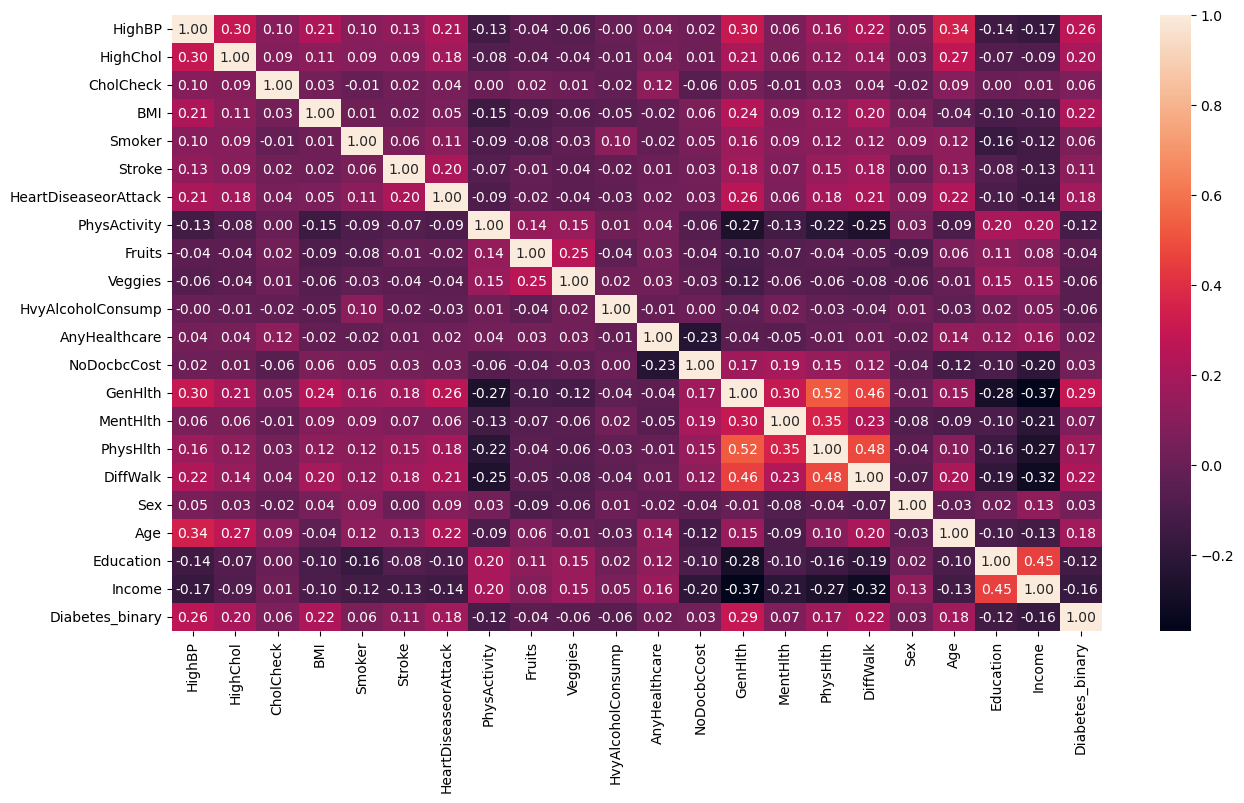

In [13]:
matriz_corr = df.corr(method='pearson')

plt.figure(figsize=(15,8))
sns.heatmap(matriz_corr, annot=True, fmt='.2f')

In [16]:
correlacao_target = df.corr()['Diabetes_binary'].sort_values(ascending=False)[1:]
correlacao_target

GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Fruits                 -0.040779
Veggies                -0.056584
HvyAlcoholConsump      -0.057056
PhysActivity           -0.118133
Education              -0.124456
Income                 -0.163919
Name: Diabetes_binary, dtype: float64

**Lista das Variáveis**

In [17]:
variaveis = [
    "HighBP",                 # Pressão alta
    "HighChol",               # Colesterol alto
    "CholCheck",              # Fez exame de colesterol
    "BMI",                    # Índice de massa corporal
    "Smoker",                 # Fumante
    "Stroke",                 # AVC (derrame)
    "HeartDiseaseorAttack",   # Doença cardíaca ou ataque cardíaco
    "PhysActivity",           # Atividade física
    "Fruits",                 # Consome frutas
    "Veggies",                # Consome vegetais
    "HvyAlcoholConsump",      # Consumo excessivo de álcool
    "AnyHealthcare",          # Tem acesso a cuidados de saúde
    "NoDocbcCost",            # Não consultou por custo
    "GenHlth",                # Saúde geral
    "MentHlth",               # Saúde mental (nº dias ruim)
    "PhysHlth",               # Saúde física (nº dias ruim)
    "DiffWalk",               # Dificuldade para caminhar
    "Sex",                    # Sexo
    "Age",                    # Idade
    "Education",              # Escolaridade
    "Income",                 # Renda
    "Diabetes_binary"         # Possui diabetes (1 = sim, 0 = não)
    ]

**Separando os Dados de treino e de teste**

In [18]:
from sklearn.model_selection import train_test_split

X= df.drop('Diabetes_binary', axis = 1)
y = df['Diabetes_binary'].astype(int)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 101)

In [19]:
# Verificou-se que a distribuição de dados não está correta
y_train.value_counts()

Diabetes_binary
0    152958
1     24618
Name: count, dtype: int64

**Equilibrando os dados**

In [20]:
"""
Utilizou o classe RandomUnderSampler da biblioteca imbalanced-learn, 
com o objetivo de equilibrar as classes do conjunto de dados, 
para assim evitar um possível overfitting.
"""
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
x_train_res, y_train_res = rus.fit_resample(x_train, y_train)

# Verificando a distribuição dos dados
y_train_res.value_counts()


Diabetes_binary
0    24618
1    24618
Name: count, dtype: int64

**Árvore de Decisão**

In [21]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(max_depth=6, min_samples_leaf=0.05)
dtree.fit(x_train_res, y_train_res)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=0.05)

**Previsões e Avaliações**

In [25]:
y_pred = dtree.predict(x_train)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_train, y_pred))
print(confusion_matrix(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.66      0.78    152958
           1       0.27      0.78      0.40     24618

    accuracy                           0.67    177576
   macro avg       0.61      0.72      0.59    177576
weighted avg       0.85      0.67      0.72    177576

[[100641  52317]
 [  5396  19222]]


In [26]:
y_pred_test = dtree.predict(x_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_test))
print(confusion_matrix(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.95      0.66      0.78     65376
           1       0.28      0.79      0.41     10728

    accuracy                           0.68     76104
   macro avg       0.61      0.72      0.59     76104
weighted avg       0.86      0.68      0.73     76104

[[43184 22192]
 [ 2265  8463]]


**Visualizando a Árvore**


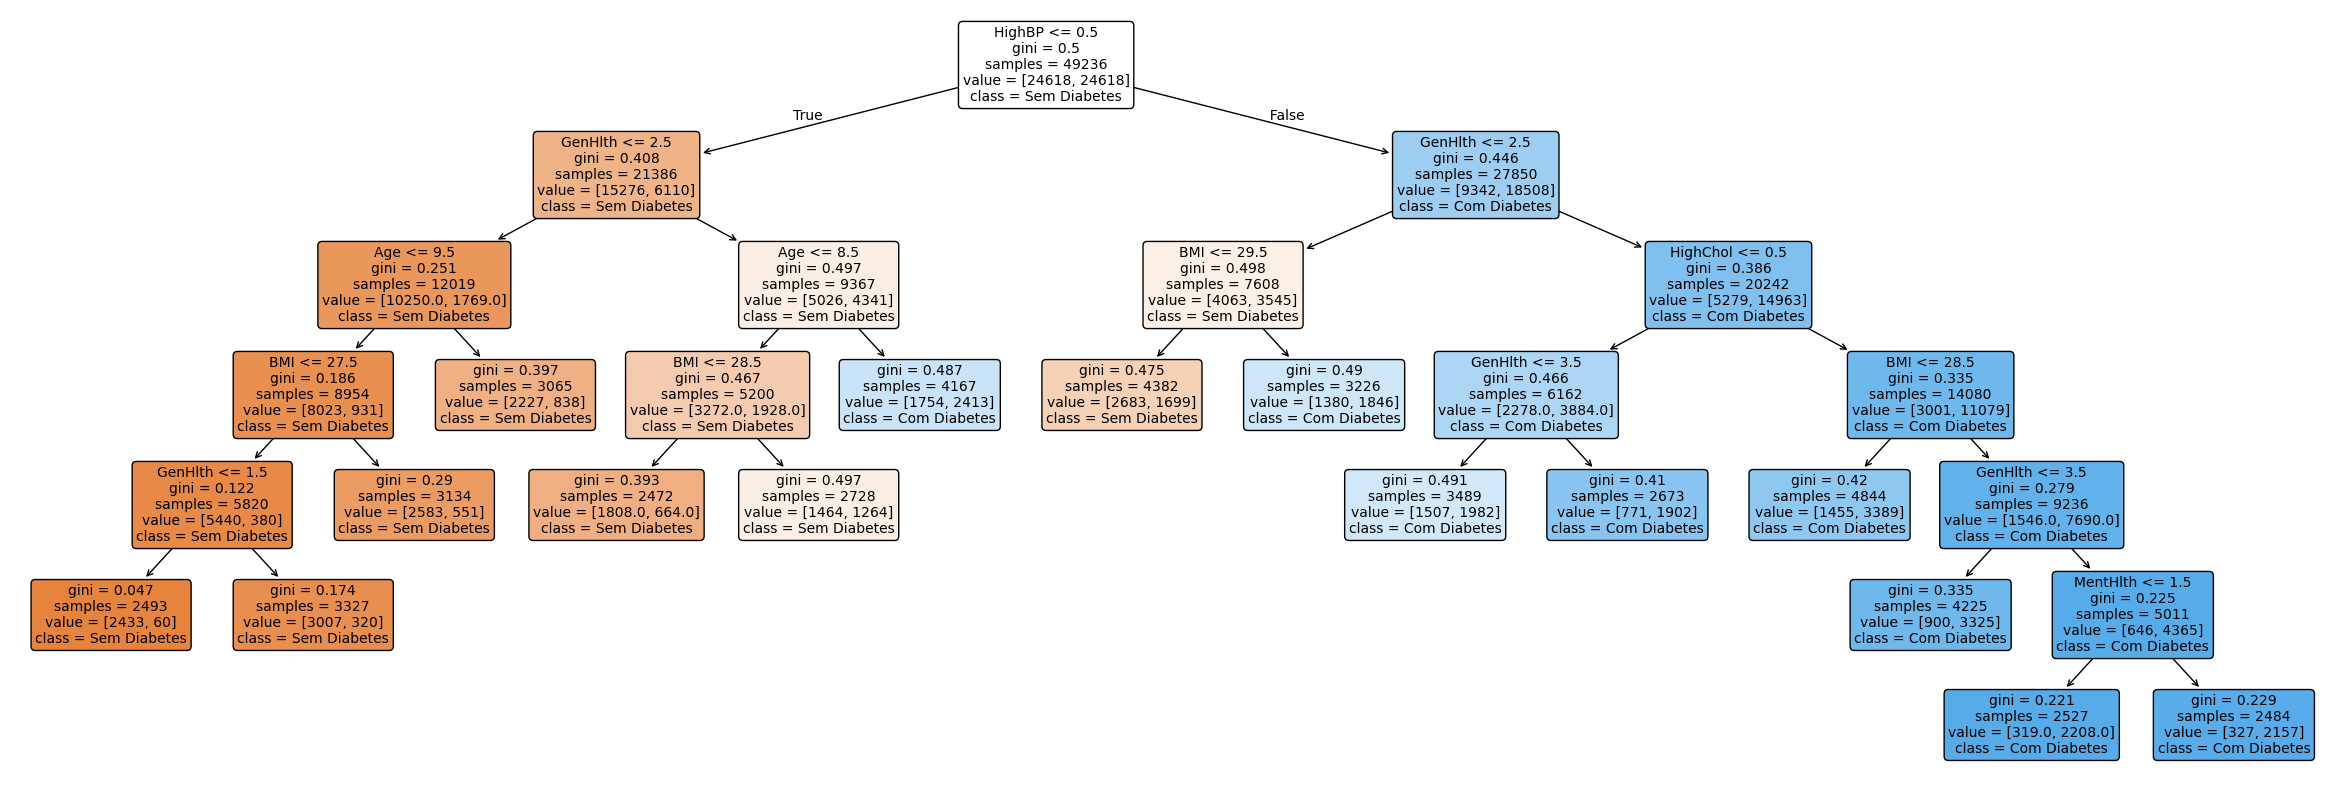

<Figure size 640x480 with 0 Axes>

In [27]:
from sklearn.tree import plot_tree

fig = plt.figure(figsize=(30, 10))
plot_tree(dtree,
          feature_names=x_train.columns,
          class_names=["Sem Diabetes", "Com Diabetes"],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()
plt.tight_layout()


**Salvando a imagem da árvore**

In [ ]:
fig.savefig('arvore_decisao.png')